In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import joblib

In [2]:
df = pd.read_csv('../../dataset/Loan.csv')

In [3]:
df.columns

Index(['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'LoanAmount',
       'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore'],
      dtype='object')

In [4]:
df["EducationLevel"].value_counts()

EducationLevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64

In [5]:
important = ["RiskScore"]

with open('important_features.txt',"r") as file:
    for i in file:
        print(i)
        important.append(i.strip())
    print(file)


PaymentHistory

LoanAmount

Age

LoanDuration

Experience

EducationLevel

BaseInterestRate

CreditCardUtilizationRate

TotalAssets

InterestRate

LengthOfCreditHistory

NetWorth

PreviousLoanDefaults

CreditScore

DebtToIncomeRatio

TotalDebtToIncomeRatio

AnnualIncome

MonthlyIncome

BankruptcyHistory

<_io.TextIOWrapper name='important_features.txt' mode='r' encoding='cp1252'>


In [6]:
# df = pd.get_dummies(df)

In [7]:
df = df[important]

In [8]:
df.head(5)

,RiskScore,PaymentHistory,LoanAmount,Age,LoanDuration,Experience,EducationLevel,BaseInterestRate,CreditCardUtilizationRate,TotalAssets,InterestRate,LengthOfCreditHistory,NetWorth,PreviousLoanDefaults,CreditScore,DebtToIncomeRatio,TotalDebtToIncomeRatio,AnnualIncome,MonthlyIncome,BankruptcyHistory
0,49.0,29,13152,45,48,22,Master,0.199652,0.354418,146111,0.227590,9,126928,0,617,0.358336,0.181077,39948,3329.000000,0
1,52.0,21,26045,38,48,15,Associate,0.207045,0.087827,53204,0.201077,9,43609,0,628,0.330274,0.389852,39709,3309.083333,0
2,52.0,20,17627,47,36,26,Bachelor,0.217627,0.137414,25176,0.212548,22,5205,0,570,0.244729,0.462157,40724,3393.666667,0
3,54.0,27,37898,58,96,34,High School,0.300398,0.267587,104822,0.300911,10,99452,0,545,0.436244,0.313098,69084,5757.000000,0
4,36.0,26,9184,37,36,17,Associate,0.197184,0.320535,244305,0.175990,27,227019,0,594,0.078884,0.070210,103264,8605.333333,0


In [9]:
describe = df.describe().T
describe.to_json("describe.json", orient="index")

<Axes: >

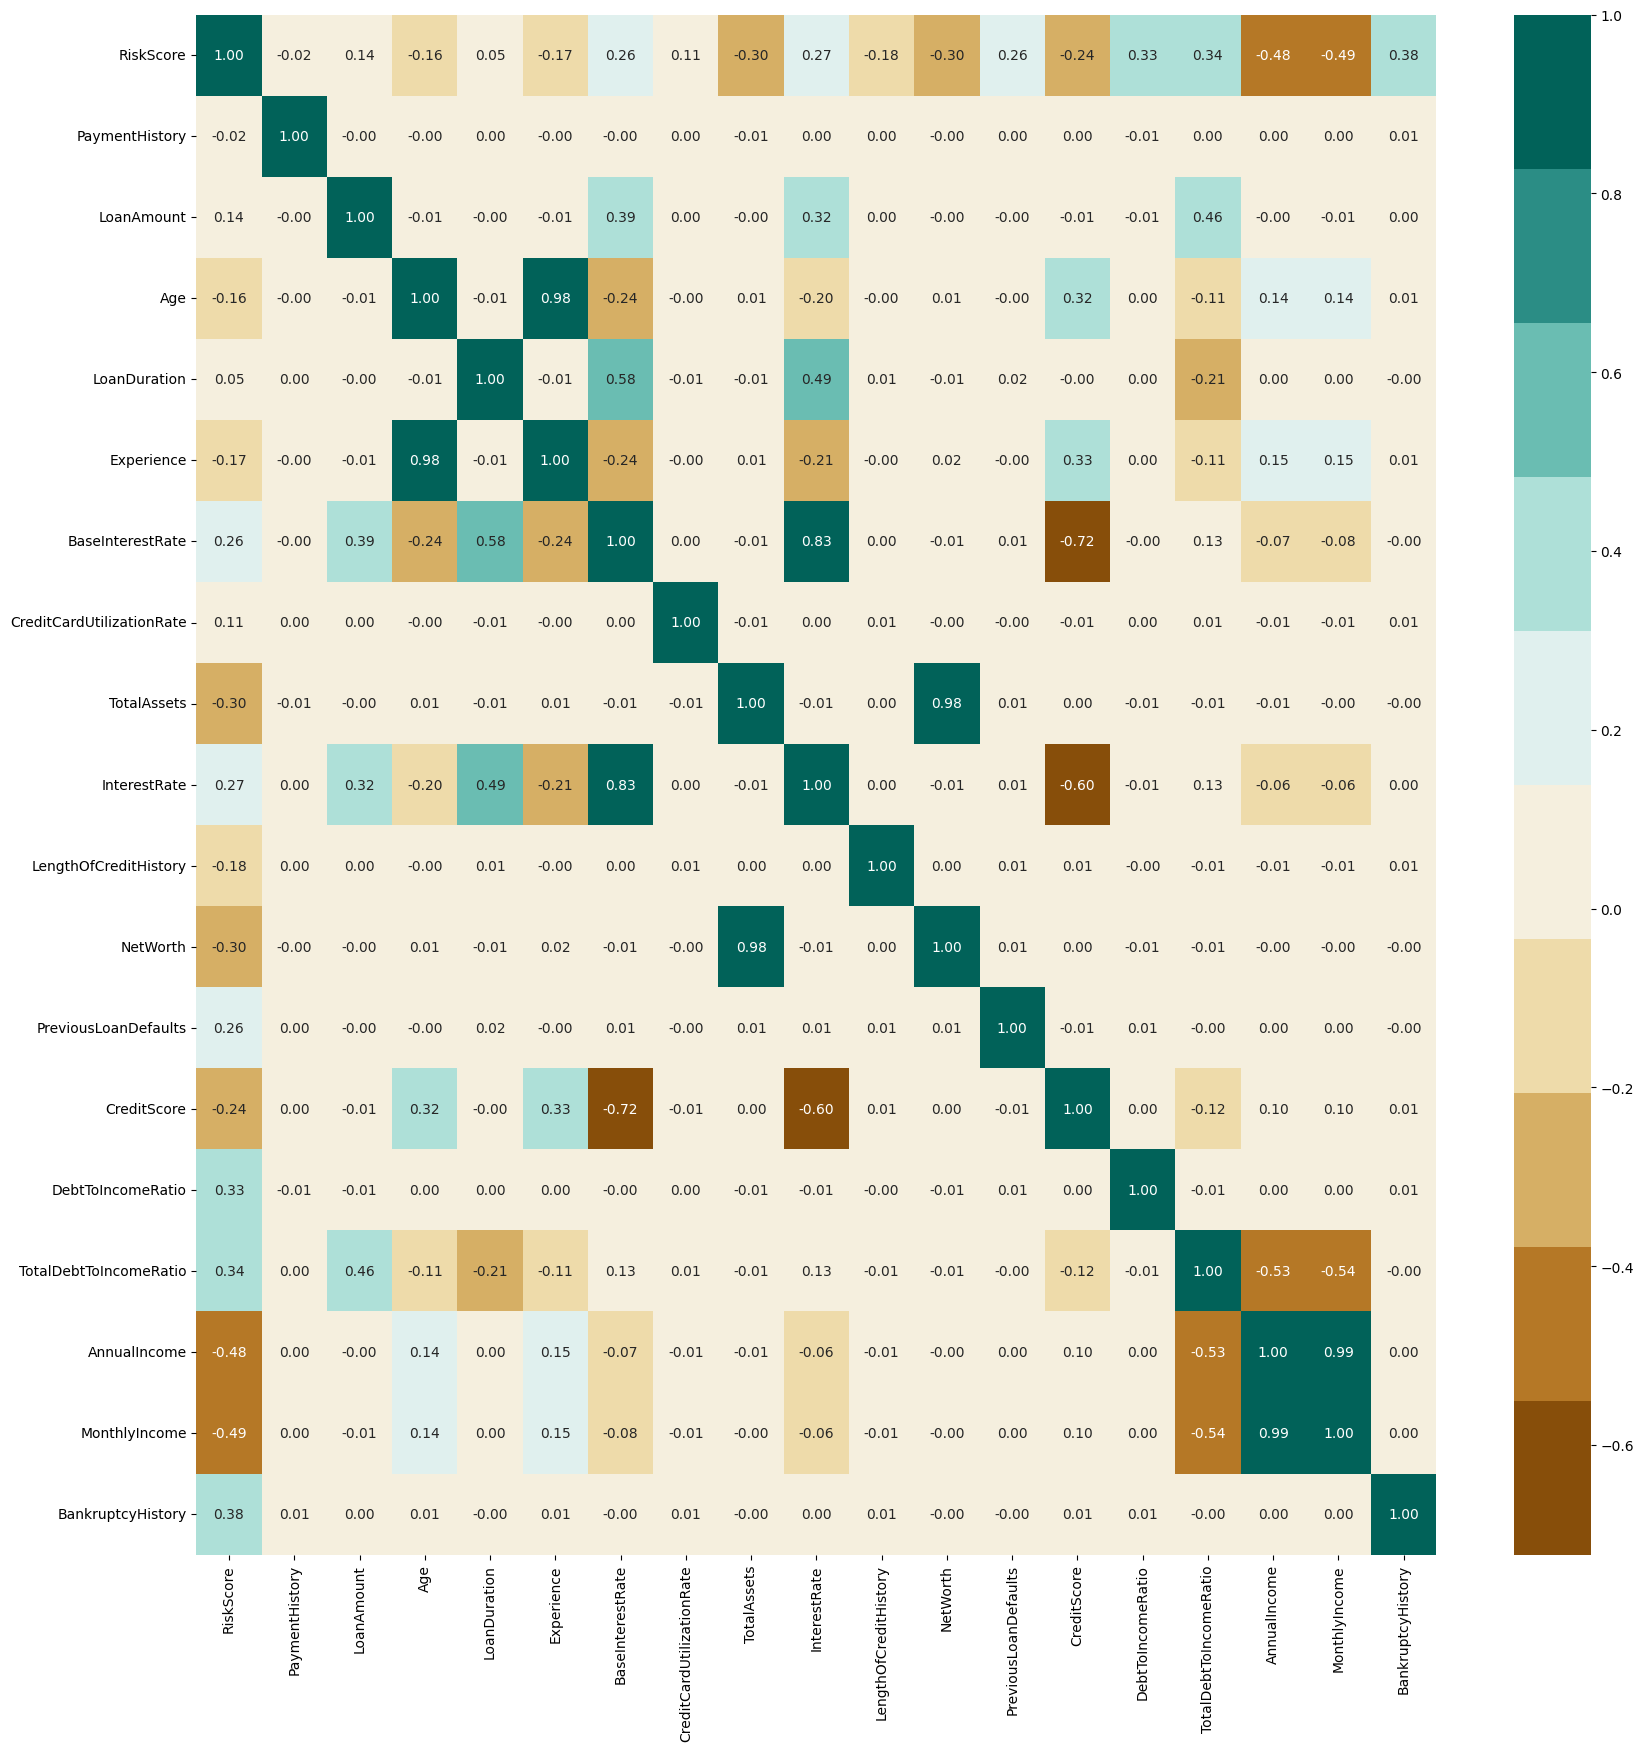

In [10]:
correlations =  df.corr(numeric_only=True)
colormap = sns.color_palette('BrBG',10)
fig, ax = plt.subplots(figsize = (20,20))
sns.heatmap(
    correlations,
    cmap=colormap,
    annot=True,
      fmt=".2f")

In [11]:
corr = df.corrwith(df["RiskScore"], numeric_only=True)
corr = corr.sort_values(ascending=False)
corr.to_json("correlation_with_risk_score.json")

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   RiskScore                  20000 non-null  float64
 1   PaymentHistory             20000 non-null  int64  
 2   LoanAmount                 20000 non-null  int64  
 3   Age                        20000 non-null  int64  
 4   LoanDuration               20000 non-null  int64  
 5   Experience                 20000 non-null  int64  
 6   EducationLevel             20000 non-null  object 
 7   BaseInterestRate           20000 non-null  float64
 8   CreditCardUtilizationRate  20000 non-null  float64
 9   TotalAssets                20000 non-null  int64  
 10  InterestRate               20000 non-null  float64
 11  LengthOfCreditHistory      20000 non-null  int64  
 12  NetWorth                   20000 non-null  int64  
 13  PreviousLoanDefaults       20000 non-null  int

In [13]:
# df = df.drop(columns=["ApplicationDate"])

In [14]:

string_df = df.select_dtypes(include=['object']).columns.tolist()
string_df



['EducationLevel']

In [15]:
encoders = {}

for col in string_df:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

joblib.dump(encoders, "encoder.pkl")


['encoder.pkl']

In [16]:
X = df.drop(columns=['RiskScore'])
feature_names = X.columns
scaler = StandardScaler()   
X= scaler.fit_transform(X)
joblib.dump(scaler, "scaler.pkl")
y = df["RiskScore"]

In [17]:
# X_train, y_train, X_test, y_test = train_test_split(X,y,test_size=0.25)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [18]:
len(y_train)

16000

In [19]:
df.columns

Index(['RiskScore', 'PaymentHistory', 'LoanAmount', 'Age', 'LoanDuration',
       'Experience', 'EducationLevel', 'BaseInterestRate',
       'CreditCardUtilizationRate', 'TotalAssets', 'InterestRate',
       'LengthOfCreditHistory', 'NetWorth', 'PreviousLoanDefaults',
       'CreditScore', 'DebtToIncomeRatio', 'TotalDebtToIncomeRatio',
       'AnnualIncome', 'MonthlyIncome', 'BankruptcyHistory'],
      dtype='object')

In [20]:
df['RiskScore'].describe()

count    20000.000000
mean        50.766780
std          7.778262
min         28.800000
25%         46.000000
50%         52.000000
75%         56.000000
max         84.000000
Name: RiskScore, dtype: float64

In [21]:
def training(model):
    predict = model.predict(X_test)
    print(predict)
    rmse = root_mean_squared_error(y_test, predict)
    print(rmse)
    accuracy = r2_score(y_test,predict)
    print(accuracy)
    return model

def feature_selection(model):
    important_feature = []
    importances = model.feature_importances_
    feature_ranking = pd.Series(importances, index=feature_names)
    feature_ranking = feature_ranking.sort_values(ascending=True)

    for feature, importance in feature_ranking.items():
        if importance != 0:
            print(feature, importance)
            important_feature.append(feature)

    with open('important_features.txt', 'w') as f:  
        for feature in important_feature:
            f.write(feature + '\n')

In [22]:
model = XGBRegressor(n_estimators=500, learning_rate = 0.03, max_depth = 2, objective="reg:squarederror",)
model.fit(X_train, y_train, verbose=False)
# feature_selection(model)
training(model)


[48.333767 68.0982   51.374397 ... 51.631123 35.556877 50.987747]
2.981553303775172
0.8531248885033218


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [23]:
model.save_model("xgboostmodel.json")

In [24]:
joblib.dump(feature_names.tolist(), "features.pkl")

['features.pkl']

In [25]:
import pandas as pd

In [26]:
predict_df = pd.read_csv("prediction_data.csv")

In [27]:
predict_df.describe().T

,count,mean,std,min,25%,50%,75%,max
LoanAmount,1.0,18400.000000,NaN,18400.000000,18400.000000,18400.000000,18400.000000,18400.000000
LoanDuration,1.0,36.000000,NaN,36.000000,36.000000,36.000000,36.000000,36.000000
Age,1.0,38.000000,NaN,38.000000,38.000000,38.000000,38.000000,38.000000
InterestRate,1.0,0.385000,NaN,0.385000,0.385000,0.385000,0.385000,0.385000
BaseInterestRate,1.0,0.360000,NaN,0.360000,0.360000,0.360000,0.360000,0.360000
AnnualIncome,1.0,27600.000000,NaN,27600.000000,27600.000000,27600.000000,27600.000000,27600.000000
MonthlyIncome,1.0,2300.000000,NaN,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000
Experience,1.0,6.000000,NaN,6.000000,6.000000,6.000000,6.000000,6.000000
CreditScore,1.0,421.000000,NaN,421.000000,421.000000,421.000000,421.000000,421.000000
LengthOfCreditHistory,1.0,9.000000,NaN,9.000000,9.000000,9.000000,9.000000,9.000000
